# SAR / AML Transaction Classifier — Fixed Pipeline

**What changed vs. the previous version, and why:**

1. **No more blind 100k subsample.** The original `raw_df.sample(n=100000)` shrank an already-rare positive class (~0.1%) down to roughly 100 laundering examples total — too few for XGBoost to learn a real boundary. We now keep **all positive cases** and only optionally downsample the negative class.
2. **`scale_pos_weight` added**, tuned via grid search, so the model is actually told the classes are imbalanced.
3. **Scoring metric switched from `roc_auc` to `average_precision` (PR-AUC)** for both hyperparameter selection and evaluation — ROC-AUC is misleadingly optimistic at extreme imbalance.
4. **New behavioral/account-level features**: sender/receiver transaction frequency, deviation from an account's own average amount, cross-border flag, round-amount flag, and a "near reporting threshold" structuring flag. Raw per-transaction fields alone rarely separate laundering from legitimate activity well.
5. **Threshold selection now uses the precision-recall curve**, not the ROC curve, so we can see the actual precision we're paying at ~90% recall instead of being surprised by it downstream.

> **Known simplification to fix before production:** the account-level aggregate features below are computed over the *entire* dataset (past + future transactions relative to any given row). For a real-time SAR pipeline you'd instead compute rolling, point-in-time-only stats per account (only transactions *before* the one being scored) to avoid leaking future behavior into current-time predictions. Flagged here so it's not forgotten.

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Load data — keep the full dataset

In [17]:
raw_df = pd.read_csv("../data/SAML-D.csv")
raw_df.shape

(9504852, 12)

In [18]:
raw_df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [19]:
# Check true class imbalance BEFORE any sampling decisions
print(raw_df['Is_laundering'].value_counts())
print(raw_df['Is_laundering'].value_counts(normalize=True))

Is_laundering
0    9494979
1       9873
Name: count, dtype: int64
Is_laundering
0    0.998961
1    0.001039
Name: proportion, dtype: float64


## 2. Sampling — preserve every positive case

If the full dataset is too slow to iterate on, downsample the **negative class only**.
Never blindly `.sample()` the whole frame — that's what wiped out most of the positive
examples last time.

In [20]:
USE_FULL_DATA = False          # full dataset is too much for GridSearchCV + n_jobs=-1 on this machine
SAMPLE_NEGATIVE_N = 200_000    # keeps every positive, downsamples negatives to a workable size

if USE_FULL_DATA:
    df = raw_df.copy()
else:
    positives = raw_df[raw_df['Is_laundering'] == 1]
    negatives = raw_df[raw_df['Is_laundering'] == 0].sample(
        n=min(SAMPLE_NEGATIVE_N, (raw_df['Is_laundering'] == 0).sum()),
        random_state=1
    )
    df = pd.concat([positives, negatives]).sample(frac=1, random_state=1).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(df['Is_laundering'].value_counts())
print(f"Positive rate: {df['Is_laundering'].mean():.4%}")

Rows: 209,873
Is_laundering
0    200000
1      9873
Name: count, dtype: int64
Positive rate: 4.7043%


## 3. Quick EDA (unchanged in spirit from before)

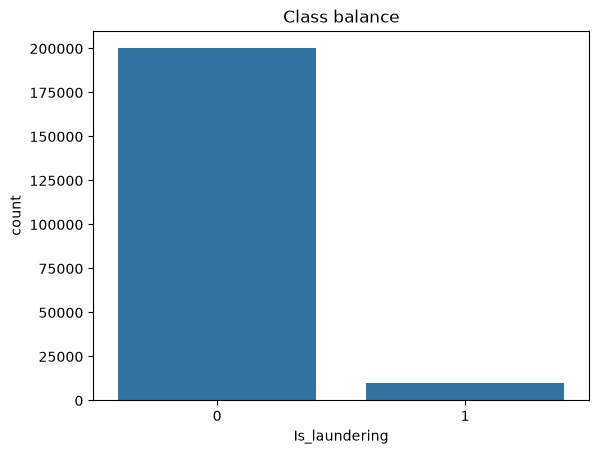

In [21]:
sns.countplot(data=df, x='Is_laundering')
plt.title("Class balance")
plt.show()

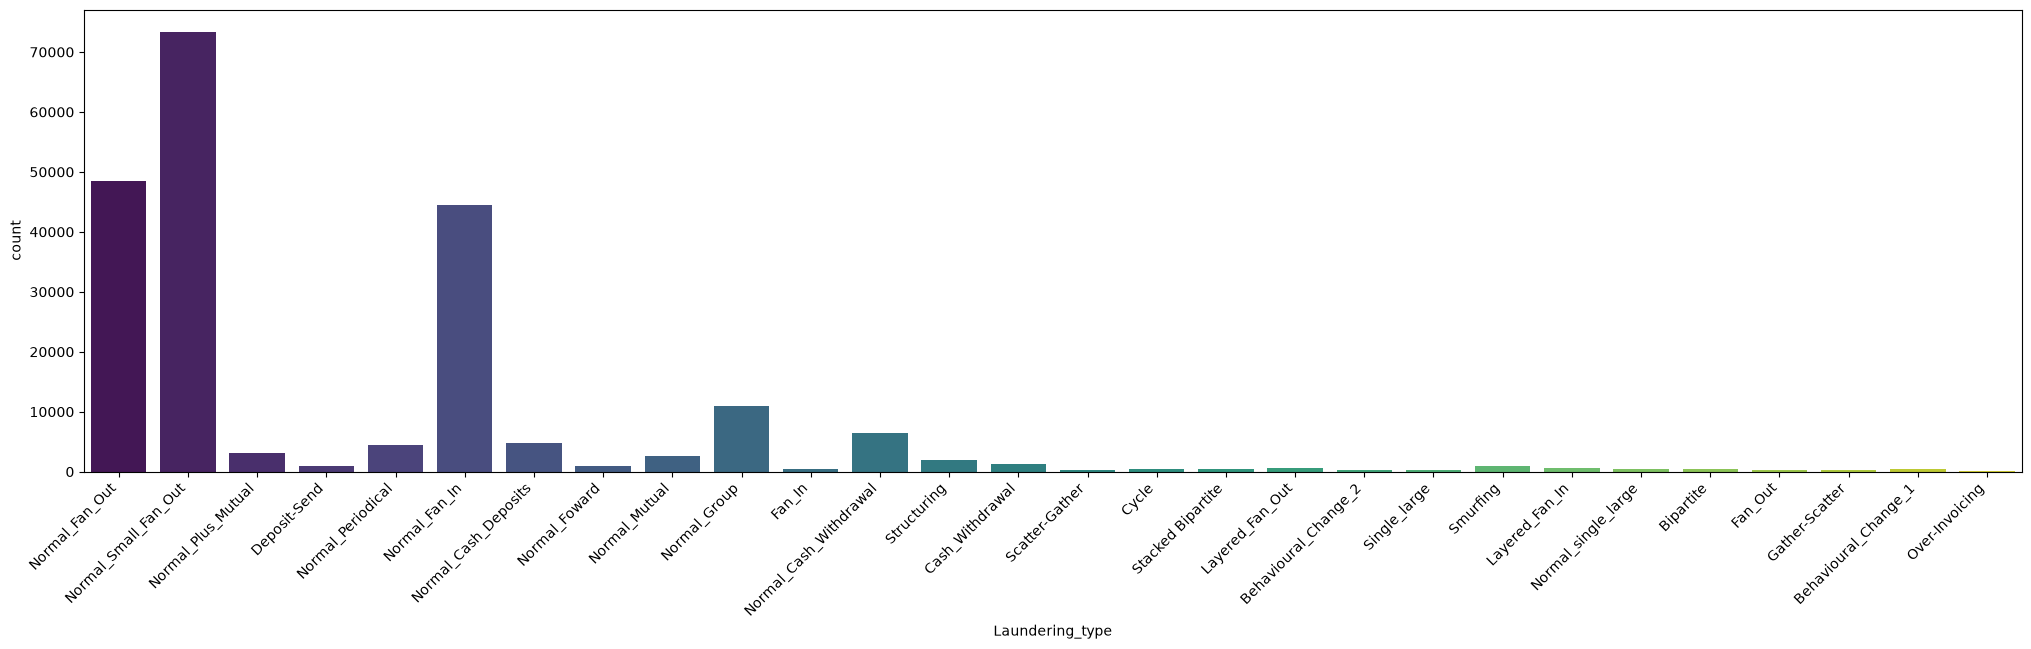

In [22]:
plt.figure(figsize=(25, 6))
sns.countplot(data=df, x='Laundering_type', palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.show()

In [23]:
laundering_stats = df[df['Is_laundering'] == 1]['Amount'].agg(['max', 'mean', 'min'])
normal_stats = df[df['Is_laundering'] == 0]['Amount'].agg(['max', 'mean', 'min'])

print("Laundering Transactions Stats:\n", laundering_stats)
print("\nNormal Transactions Stats:\n", normal_stats)

Laundering Transactions Stats:
 max     1.261850e+07
mean    4.058767e+04
min     1.582000e+01
Name: Amount, dtype: float64

Normal Transactions Stats:
 max     986174.470000
mean      8642.877032
min          9.120000
Name: Amount, dtype: float64


## 4. Date features

In [24]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

## 5. Behavioral / account-level features (new)

This is the highest-leverage feature-engineering addition. Per-transaction fields
(amount, currency, payment type) rarely separate laundering from normal activity on
their own — laundering shows up more in *patterns*: unusual frequency, amounts that
deviate from an account's own norm, cross-border movement, and amounts shaped to dodge
reporting thresholds ("structuring").

In [25]:
# Sender behavior
sender_stats = df.groupby('Sender_account')['Amount'].agg(['count', 'mean', 'std']).rename(
    columns={'count': 'Sender_txn_count', 'mean': 'Sender_avg_amount', 'std': 'Sender_std_amount'}
)
df = df.merge(sender_stats, on='Sender_account', how='left')
df['Sender_std_amount'] = df['Sender_std_amount'].fillna(0)

# Receiver behavior
receiver_stats = df.groupby('Receiver_account')['Amount'].agg(['count', 'mean']).rename(
    columns={'count': 'Receiver_txn_count', 'mean': 'Receiver_avg_amount'}
)
df = df.merge(receiver_stats, on='Receiver_account', how='left')

# How far this transaction deviates from the sender's own typical amount
df['Amount_dev_from_sender_avg'] = (
    (df['Amount'] - df['Sender_avg_amount']) / (df['Sender_std_amount'] + 1)
)

# Cross-border transfer
df['Is_cross_border'] = (df['Sender_bank_location'] != df['Receiver_bank_location']).astype(int)

# Round-number amount (common camouflage pattern)
df['Is_round_amount'] = (df['Amount'] % 1000 == 0).astype(int)

# Structuring signal: just under a common reporting threshold (e.g. $10,000)
df['Near_reporting_threshold'] = ((df['Amount'] >= 9000) & (df['Amount'] < 10000)).astype(int)

df[['Sender_txn_count', 'Receiver_txn_count', 'Amount_dev_from_sender_avg',
    'Is_cross_border', 'Is_round_amount', 'Near_reporting_threshold']].describe()

,Sender_txn_count,Receiver_txn_count,Amount_dev_from_sender_avg,Is_cross_border,Is_round_amount,Near_reporting_threshold
count,209873.000000,209873.000000,2.098730e+05,209873.000000,209873.000000,209873.000000
mean,7.403368,3.105997,1.472729e-17,0.107984,0.000010,0.046957
std,5.458296,4.340498,8.079568e-01,0.310361,0.003087,0.211547
min,1.000000,1.000000,-2.608945e+00,0.000000,0.000000,0.000000
25%,2.000000,1.000000,-5.919085e-01,0.000000,0.000000,0.000000
50%,7.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
75%,11.000000,3.000000,3.137826e-01,0.000000,0.000000,0.000000
max,40.000000,47.000000,5.598083e+00,1.000000,1.000000,1.000000


## 6. Drop leakage / unusable columns

In [26]:
columns_to_drop = ['Time', 'Date']
df.drop(columns=columns_to_drop, inplace=True)
df.columns

Index(['Sender_account', 'Receiver_account', 'Amount', 'Payment_currency',
       'Received_currency', 'Sender_bank_location', 'Receiver_bank_location',
       'Payment_type', 'Is_laundering', 'Laundering_type', 'Year', 'Month',
       'Day', 'Week', 'Sender_txn_count', 'Sender_avg_amount',
       'Sender_std_amount', 'Receiver_txn_count', 'Receiver_avg_amount',
       'Amount_dev_from_sender_avg', 'Is_cross_border', 'Is_round_amount',
       'Near_reporting_threshold'],
      dtype='str')

In [27]:
numeric_cols = df.select_dtypes(exclude="object").columns
categorical_cols_all = df.select_dtypes(include="object").columns
print("Numeric:", list(numeric_cols))
print("Categorical:", list(categorical_cols_all))

Numeric: ['Sender_account', 'Receiver_account', 'Amount', 'Is_laundering', 'Year', 'Month', 'Day', 'Week', 'Sender_txn_count', 'Sender_avg_amount', 'Sender_std_amount', 'Receiver_txn_count', 'Receiver_avg_amount', 'Amount_dev_from_sender_avg', 'Is_cross_border', 'Is_round_amount', 'Near_reporting_threshold']
Categorical: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Laundering_type']


## 7. Build X / y

Explicitly listing which columns to one-hot encode instead of slicing `categorical_cols[:-1]` —
the old slice silently dropped whatever happened to sit last in column order, which is
fragile and easy to get wrong (e.g. accidentally leaving a real feature un-encoded, or
accidentally keeping `Laundering_type`, which is a direct leak of the target).

In [28]:
leak_and_id_cols = [
    "Is_laundering",       # target
    "Laundering_type",     # only defined when Is_laundering == 1 -> direct leakage
    "Sender_account",      # raw ID, already summarized into Sender_* features
    "Receiver_account",    # raw ID, already summarized into Receiver_* features
]

categorical_cols = [
    "Payment_currency",
    "Received_currency",
    "Sender_bank_location",
    "Receiver_bank_location",
    "Payment_type",
]

X = df.drop(columns=leak_and_id_cols)
y = df["Is_laundering"]

for col in categorical_cols:
    print(col, "->", df[col].nunique(), "unique values")

Payment_currency -> 13 unique values
Received_currency -> 13 unique values
Sender_bank_location -> 18 unique values
Receiver_bank_location -> 18 unique values
Payment_type -> 7 unique values


### Native categorical support instead of one-hot encoding

At ~9.5M rows, `pd.get_dummies` tries to materialize a dense array and can blow past
available RAM (`MemoryError`) even for modest-cardinality columns like bank location.
Instead, we mark these columns as pandas `category` dtype and let XGBoost split on
categories directly (`enable_categorical=True`, `tree_method='hist'`). This avoids the
memory blow-up entirely, scales to the full dataset, and generally performs as well or
better than one-hot for this kind of field.

In [29]:
for col in categorical_cols:
    X[col] = X[col].astype('category')

# Downcast numeric dtypes too -- default int64/float64 is wasteful at this row count
for col in X.select_dtypes(include=['int64']).columns:
    X[col] = pd.to_numeric(X[col], downcast='integer')
for col in X.select_dtypes(include=['float64']).columns:
    X[col] = pd.to_numeric(X[col], downcast='float')

X.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 209873 entries, 0 to 209872
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   Amount                      209873 non-null  float64 
 1   Payment_currency            209873 non-null  category
 2   Received_currency           209873 non-null  category
 3   Sender_bank_location        209873 non-null  category
 4   Receiver_bank_location      209873 non-null  category
 5   Payment_type                209873 non-null  category
 6   Year                        209873 non-null  int32   
 7   Month                       209873 non-null  int32   
 8   Day                         209873 non-null  int32   
 9   Week                        209873 non-null  int8    
 10  Sender_txn_count            209873 non-null  int8    
 11  Sender_avg_amount           209873 non-null  float64 
 12  Sender_std_amount           209873 non-null  float64 
 13  Receiver_t

## 8. Train/test split (stratified, unchanged)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

(167898, 19) (41975, 19)
Train positive rate: 0.047040465044253056
Test positive rate: 0.04705181655747469


## 9. Model — with imbalance handling and the right scoring metric

- `scale_pos_weight` tells XGBoost how much more to weight the rare positive class.
- `scoring='average_precision'` (PR-AUC) drives hyperparameter selection instead of
  `roc_auc`, since PR-AUC is far more sensitive to the false-positive blowup we saw before.
- `StratifiedKFold` keeps a proportional number of positives in every CV fold instead of
  letting `GridSearchCV`'s default splitting risk folds with almost no positive examples.

In [31]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

neg, pos = np.bincount(y_train)
base_scale_pos_weight = neg / pos
print(f"neg={neg}, pos={pos}, base scale_pos_weight={base_scale_pos_weight:.1f}")

param_grid = {
    'max_depth': [4, 8],
    'eta': [0.05, 0.2],
    'scale_pos_weight': [base_scale_pos_weight, base_scale_pos_weight * 1.5],
}

xgb = XGBClassifier(
    eval_metric='aucpr',
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',       # required for native categorical support
    enable_categorical=True,  # split directly on category columns, no one-hot needed
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    verbose=2,
    n_jobs=-1,  # if this still hits MemoryError, lower to n_jobs=2 or 1 --
                # each parallel worker holds its own copy of the training data
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

neg=160000, pos=7898, base scale_pos_weight=20.3
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'eta': 0.2, 'max_depth': 8, 'scale_pos_weight': np.float64(30.387439858191946)}


## 10. Evaluate with the Precision-Recall curve (the metric that matters here)

Test PR-AUC:  0.8905
Test ROC-AUC: 0.9764  (reported for reference only — don't optimize on this)


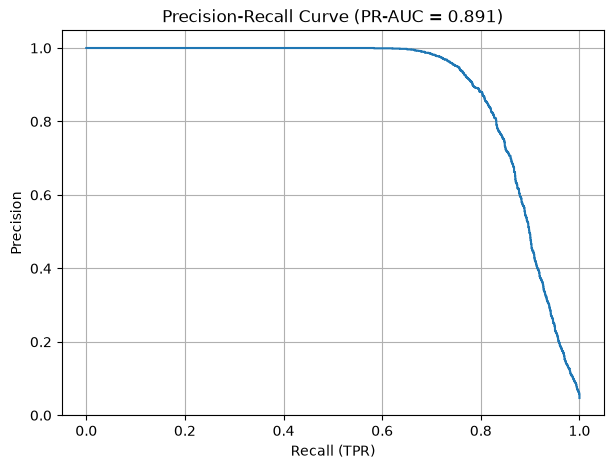

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

test_probabilities = best_model.predict_proba(X_test)[:, 1]

avg_precision = average_precision_score(y_test, test_probabilities)
roc_auc = roc_auc_score(y_test, test_probabilities)
print(f"Test PR-AUC:  {avg_precision:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}  (reported for reference only — don't optimize on this)")

precision, recall, pr_thresholds = precision_recall_curve(y_test, test_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall (TPR)")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (PR-AUC = {avg_precision:.3f})")
plt.grid(True)
plt.show()

## 11. Pick a threshold for ~90% recall — off the PR curve, not the ROC curve

Among all thresholds that hit at least the desired recall, we pick the one with the
**highest precision**, so we're not leaving precision on the table unnecessarily.

In [33]:
desired_recall = 0.90

valid_idx = np.where(recall[:-1] >= desired_recall)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precision[valid_idx])]
    chosen_threshold = pr_thresholds[best_idx]
else:
    # couldn't hit the target recall at all -- fall back to closest achievable
    best_idx = np.argmin(np.abs(recall[:-1] - desired_recall))
    chosen_threshold = pr_thresholds[best_idx]
    print("WARNING: could not reach desired recall; using closest achievable point.")

print(f"Chosen threshold: {chosen_threshold:.4f}")
print(f"Precision at this threshold: {precision[best_idx]:.4f}")
print(f"Recall at this threshold:    {recall[best_idx]:.4f}")

Chosen threshold: 0.1171
Precision at this threshold: 0.4929
Recall at this threshold:    0.9003


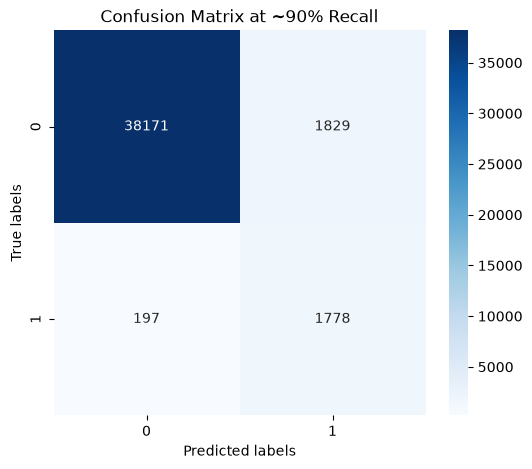

False Positive Rate (FPR): 0.046
True Positive Rate (TPR):  0.900

              precision    recall  f1-score   support

           0      0.995     0.954     0.974     40000
           1      0.493     0.900     0.637      1975

    accuracy                          0.952     41975
   macro avg      0.744     0.927     0.806     41975
weighted avg      0.971     0.952     0.958     41975



In [34]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (test_probabilities >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title(f'Confusion Matrix at ~{desired_recall*100:.0f}% Recall')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"False Positive Rate (FPR): {fp / (fp + tn):.3f}")
print(f"True Positive Rate (TPR):  {tp / (tp + fn):.3f}")
print()
print(classification_report(y_test, y_pred, digits=3))

## 12. Feature importance — sanity-check that the new behavioral features are pulling weight

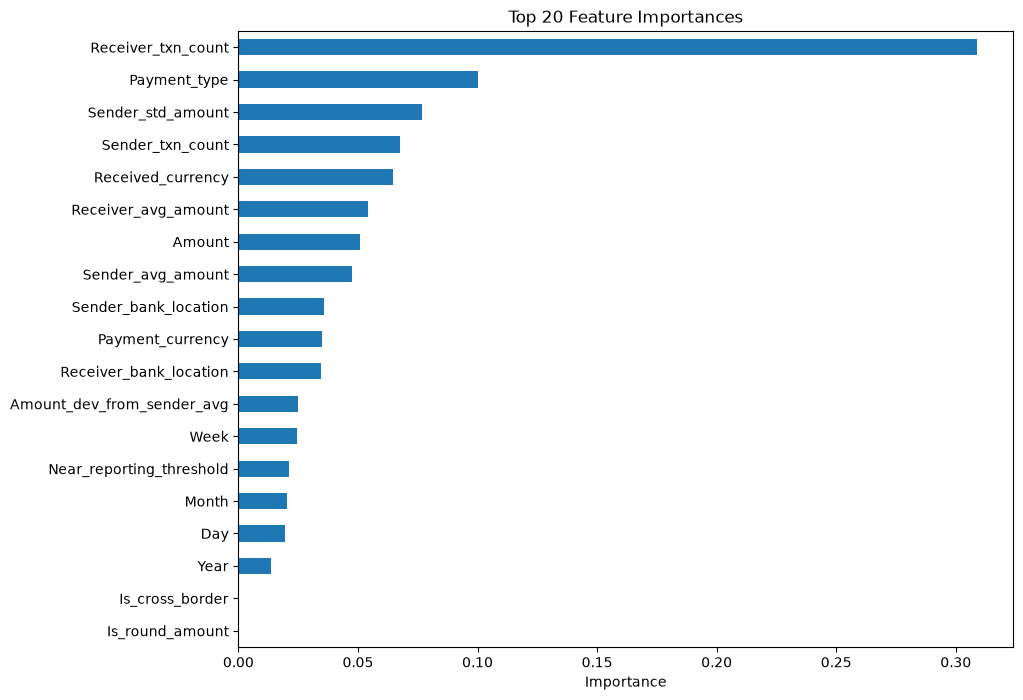

Receiver_txn_count            0.308664
Payment_type                  0.100042
Sender_std_amount             0.076620
Sender_txn_count              0.067396
Received_currency             0.064705
Receiver_avg_amount           0.054398
Amount                        0.050732
Sender_avg_amount             0.047585
Sender_bank_location          0.035929
Payment_currency              0.034878
Receiver_bank_location        0.034339
Amount_dev_from_sender_avg    0.024978
Week                          0.024395
Near_reporting_threshold      0.021185
Month                         0.020251
Day                           0.019685
Year                          0.013782
Is_cross_border               0.000437
Is_round_amount               0.000000
dtype: float32

In [35]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()

importances.head(20)

## Next steps

- If PR-AUC / precision at 90% recall is still weak, the next lever is **more/better features** before touching the model further: rolling time-windowed account stats (computed point-in-time, not over the full dataset), transaction-graph features (shared counterparties, fan-in/fan-out patterns), and peer-group deviation (how unusual is this account vs. similar accounts).
- Once this model reliably casts a **recall-oriented net** (catches ~90% of true cases, even with imperfect precision), that's exactly the right handoff point for a LangGraph "alert investigator" agent layer: it takes the flagged subset, pulls in account history / KYC context the tabular model can't see, and does the precision work — deciding escalate vs. dismiss with an explanation trail for compliance.